In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

In [5]:
import illustris_python as il

In [6]:
from astropy import units as u

In [7]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:80% !important; }</style>"))

/tmp/ipykernel_39066/82325636.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [8]:
%load_ext autoreload
%autoreload 2

In [9]:
def plot_histogram(df, prop, labels=None, bins=100, log=True):
    scale = 0.5
    labelsize = 55*scale
    x_tick_major_size = 16*scale
    x_tick_major_width = 4*scale
    x_tick_minor_size = 8*scale
    x_tick_minor_width = 3*scale
    fig_width = 25*scale
    fig_height = 15*scale
    axes_width = 3*scale
    tick_labelsize = 35*scale
    
    plt.rcParams["figure.figsize"] = (fig_width, fig_height)
    plt.rc('axes', linewidth=axes_width)
    plt.rc('xtick', labelsize=tick_labelsize) 
    plt.rc('ytick', labelsize=tick_labelsize) 
        
    ax = plt.axes()
    ax.tick_params(length=x_tick_major_size, width=x_tick_major_width)
    ax.tick_params(length=x_tick_minor_size, width=x_tick_minor_width, which='minor')
    if log:
        input_val = np.log10(df[prop])
    else:
        input_val = df[prop]
    ax.hist(input_val, bins=100, density=True)
    
    if labels != None:
        ax.set_xlabel(labels['x'], size=labelsize)
        ax.set_ylabel(labels['y'], size=labelsize)
    plt.show();
    return

In [10]:
def plot_fesc_dependence(df, prop, labels=None, log=False, mode=None):
    scale = 0.5
    labelsize = 55*scale
    x_tick_major_size = 16*scale
    x_tick_major_width = 4*scale
    x_tick_minor_size = 8*scale
    x_tick_minor_width = 3*scale
    fig_width = 25*scale
    fig_height = 15*scale
    axes_width = 3*scale
    tick_labelsize = 35*scale
    scattersize = 30*scale
    legendsize = 50*scale
    
    plt.rcParams["figure.figsize"] = (fig_width, fig_height)
    plt.rc('axes', linewidth=axes_width)
    plt.rc('xtick', labelsize=tick_labelsize) 
    plt.rc('ytick', labelsize=tick_labelsize) 
        
    ax = plt.axes()
    ax.tick_params(length=x_tick_major_size, width=x_tick_major_width)
    ax.tick_params(length=x_tick_minor_size, width=x_tick_minor_width, which='minor')


    modes = ['r', '2r', 'sf_r', 'sf_2r']
    
    if log:
        input_val = np.log10(df[prop])
    else:
        input_val = df[prop]

    if mode == None:
        for mode, label in zip(modes, plt_labels):
            ax.scatter(input_val, df['f_esc_'+mode], s=scattersize, label=label)
    else:
        ax.scatter(input_val, df['f_esc_'+mode], s=scattersize)
    
    if labels != None:
        ax.set_xlabel(labels['x'], size=labelsize)
        ax.set_ylabel(labels['y'], size=labelsize)
    plt.legend(fontsize=legendsize)
    plt.ylim(0, 1.05)
    plt.show()
    return

In [34]:
def plot_prop_dependence(df, prop_x, prop_y, labels=None, log_x=False, log_y=False, xlim=None, ylim=None):
    scale = 0.5
    labelsize = 55*scale
    x_tick_major_size = 16*scale
    x_tick_major_width = 4*scale
    x_tick_minor_size = 8*scale
    x_tick_minor_width = 3*scale
    fig_width = 25*scale
    fig_height = 15*scale
    axes_width = 3*scale
    tick_labelsize = 35*scale
    scattersize = 30*scale
    legendsize = 50*scale
    
    plt.rcParams["figure.figsize"] = (fig_width, fig_height)
    plt.rc('axes', linewidth=axes_width)
    plt.rc('xtick', labelsize=tick_labelsize) 
    plt.rc('ytick', labelsize=tick_labelsize) 
        
    ax = plt.axes()
    ax.tick_params(length=x_tick_major_size, width=x_tick_major_width)
    ax.tick_params(length=x_tick_minor_size, width=x_tick_minor_width, which='minor')
    
    if log_x:
        x_val = np.log10(df[prop_x])
    else:
        x_val = df[prop_x]

    if log_y:
        y_val = np.log10(df[prop_y])
    else:
        y_val = df[prop_y]

    ax.scatter(x_val, y_val, s=scattersize)
    
    if labels != None:
        ax.set_xlabel(labels['x'], size=labelsize)
        ax.set_ylabel(labels['y'], size=labelsize)

    if xlim != None:
        plt.xlim(xlim[0], xlim[1])
    if ylim != None:
        plt.ylim(ylim[0], ylim[1])
    plt.show()
    return

In [45]:
df['r_ratio'] = df['r_sf_r']/df['r']

In [47]:
a = df['r_ratio'].describe()

In [64]:
def describe_to_latex(desc_obj):
    print(r'\begin{tabular}{|c|c|}')
    for name, element in zip(desc_obj.index, desc_obj):
        print(r'\hline')
        name = name.replace(r'%', r'\%')
        print(name, '&', '{:.2f}'.format(element), r'\\')
    print(r'\hline')
    print(r'\end{tabular}')
    return

/freya/u/ivkos/conda-envs/semianalytic/lib/python3.10/site-packages/pandas/core/arraylike.py:397: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


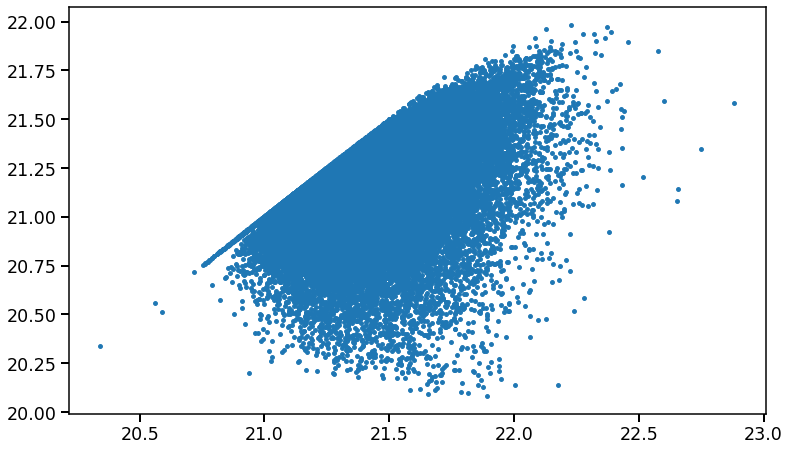

In [44]:
plot_prop_dependence(df, 'r', 'r_sf_r', labels=None, log_x=True, log_y=True)

/freya/u/ivkos/conda-envs/semianalytic/lib/python3.10/site-packages/pandas/core/arraylike.py:397: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


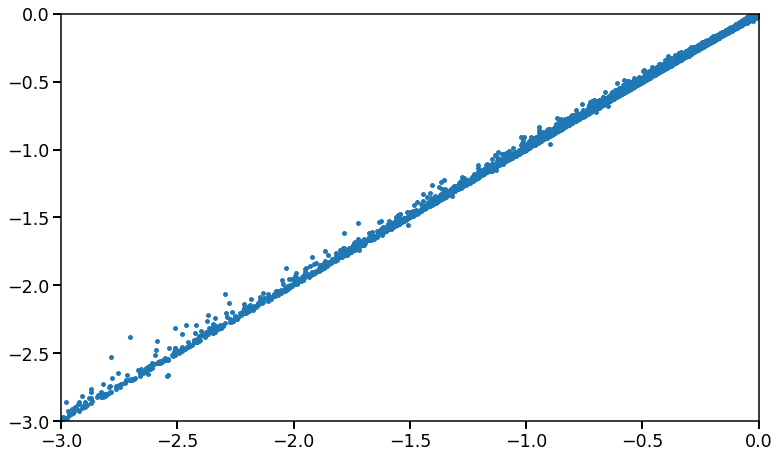

In [33]:
plot_prop_dependence(df, 'f_esc_sf_r', 'f_esc_r', labels=None, log_x=True, log_y=True, xlim=(-3,0), ylim=(-3,0))

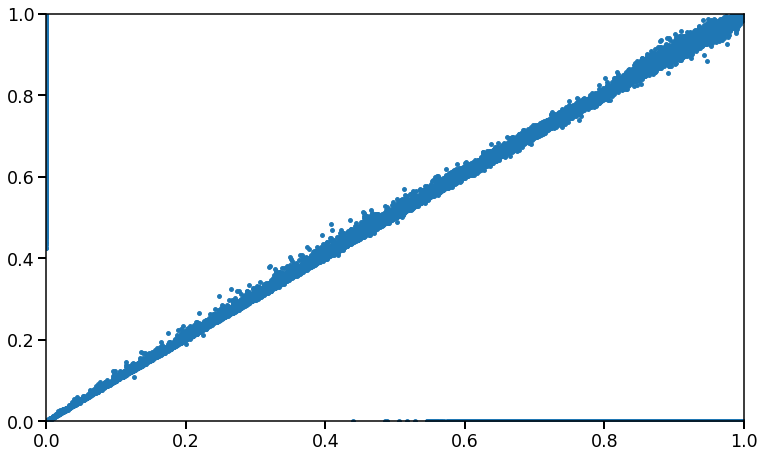

In [35]:
plot_prop_dependence(df, 'f_esc_sf_r', 'f_esc_r', labels=None, log_x=False, log_y=False, xlim=(0,1), ylim=(0,1))

In [40]:
df[(df['f_esc_sf_r']<0.1) & (df['f_esc_r']>0.4)][['f_esc_r','f_esc_sf_r']].describe()

,f_esc_r,f_esc_sf_r
count,2678.000000,2678.0
mean,0.762180,0.0
std,0.132403,0.0
min,0.424303,0.0
25%,0.660077,0.0
50%,0.775601,0.0
75%,0.873831,0.0
max,0.998814,0.0


In [39]:
df[(df['f_esc_r']<0.1) & (df['f_esc_sf_r']>0.4)][['f_esc_r','f_esc_sf_r']].describe()

,f_esc_r,f_esc_sf_r
count,34309.0,34309.000000
mean,0.0,0.898801
std,0.0,0.063439
min,0.0,0.439602
25%,0.0,0.871362
50%,0.0,0.911718
75%,0.0,0.942472
max,0.0,0.999508


In [ ]:
plt.scatter(df['f_g_r'], np.log10(df['Sigma_SFR_r']/conv**2), s=10, c=df['f_esc_r'])
plt.xlabel('$f_{gas,r}$', size=50)
plt.ylabel('$\log (\Sigma_\mathrm{SFR})[M_\odot\mathrm{kpc}^{-2}\mathrm{yr}^{-1}]$', size=50)
cbar = plt.colorbar()
cbar.set_label('$f_\mathrm{esc}$', size=50)

In [41]:
df.columns

Index(['Z_2r', 'Z_r', 'r', 'SFR_r', 'SFR_2r', 'Halo_pos_x', 'Halo_pos_y',
       'Halo_pos_z', 'M_gas_2r', 'V_2r',
       ...
       'w_sf_r', 'w_sf_2r', 'N_red_r', 'N_red_2r', 'N_red_sf_r', 'N_red_sf_2r',
       'f_esc_r', 'f_esc_2r', 'f_esc_sf_r', 'f_esc_sf_2r'],
      dtype='object', length=127)

In [11]:
full_path = f'/ptmp/mpa/ivkos/semianalytic_fesc/sn013/full_df.pickle'
df = pd.read_pickle(full_path)

In [206]:
g_to_msun = (1*u.g).to(u.Msun).value
df['M_gas_sun'] = df['M_gas_r']*g_to_msun
df['M_star_sun'] = df['M_star_r']*g_to_msun

In [213]:
cm_to_kpc = (1 * u.cm).to(u.kpc).value
area = df['r']**2*np.pi
df['ionizing_em'] = df["Tot_Ion_em_r"]/area

In [222]:
(df['Tot_Ion_em_r']*df['f_esc_sf_r']).sum()/df['Tot_Ion_em_r'].sum()

0.11066221503753845

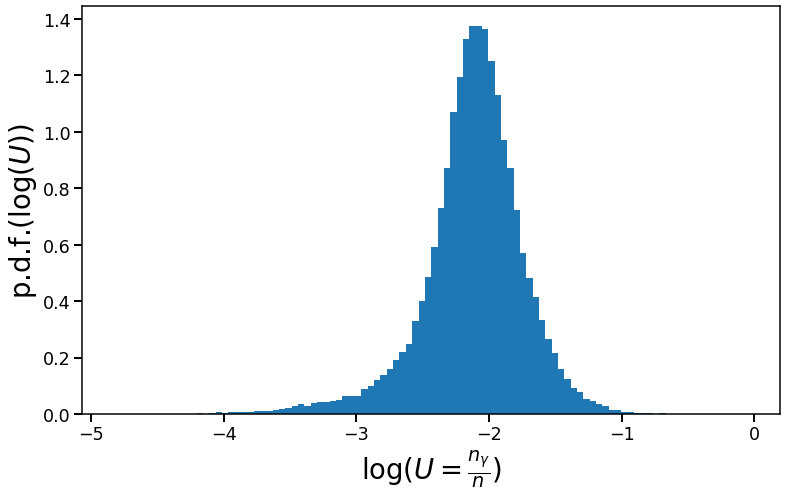

In [224]:
labels = {}
labels['x'] = r'$\log(U=\frac{n_\gamma}{n})$'
labels['y'] = 'p.d.f.($\log(U)$)'
plot_histogram(df[df['U_r']>0], 'U_r', labels=labels, bins=100, log=True)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


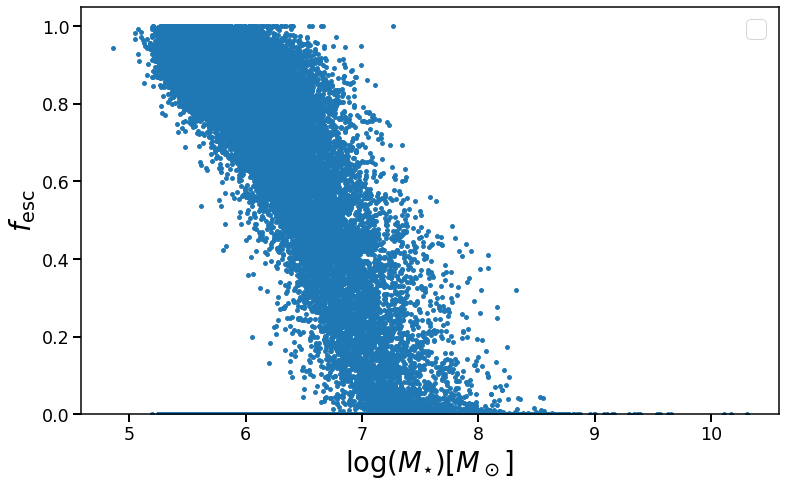

In [230]:
labels = {}
labels['x'] = r'$\log(M_\mathrm{\star})[M_\odot]$'
labels['y'] = '$f_\mathrm{esc}$'
plot_fesc_dependence(df, 'M_star_sun', labels=labels, log=True, mode='sf_r')

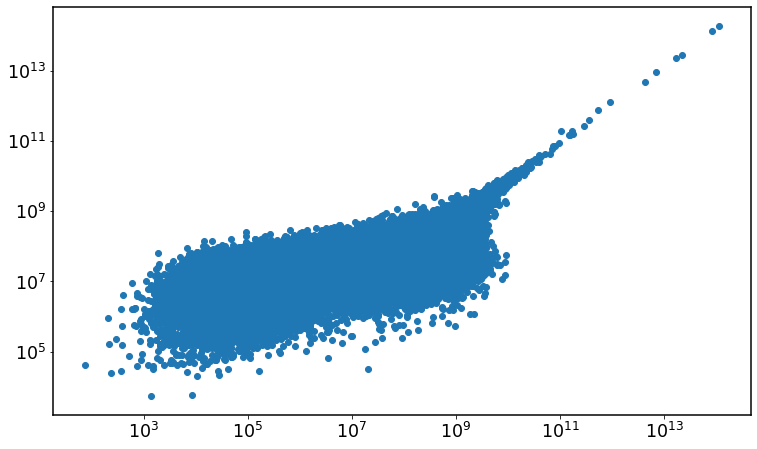

In [214]:
plt.scatter(df["ionizing_em"], df["Ion_flux_r"])
plt.yscale('log')
plt.xscale('log')

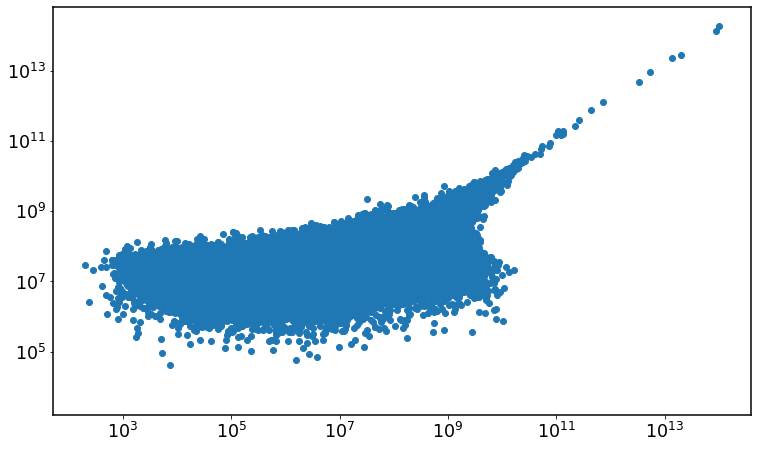

In [210]:
plt.scatter(df["Ion_flux_sf_r"], df["Ion_flux_r"])
plt.yscale('log')
plt.xscale('log')

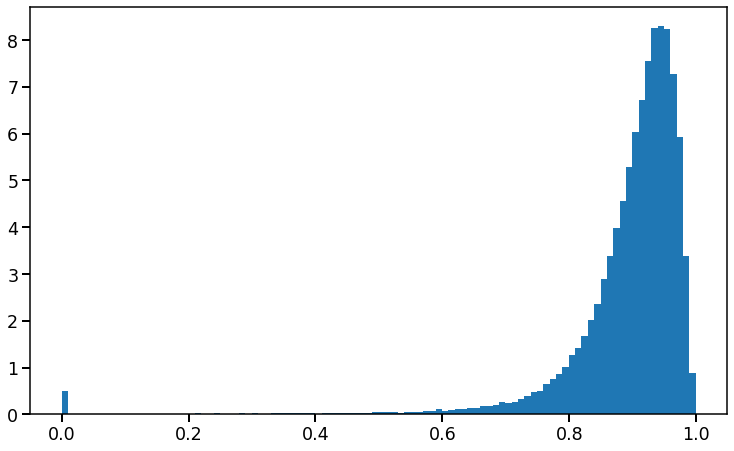

In [152]:
plot_histogram(df, 'f_g_r', labels=None, bins=100, log=False)

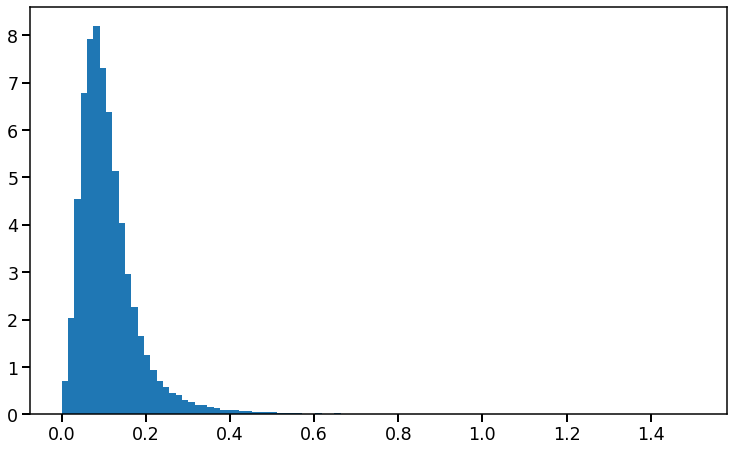

In [157]:
plot_histogram(df, 'Dust_norm_r', labels=None, bins=100, log=False)

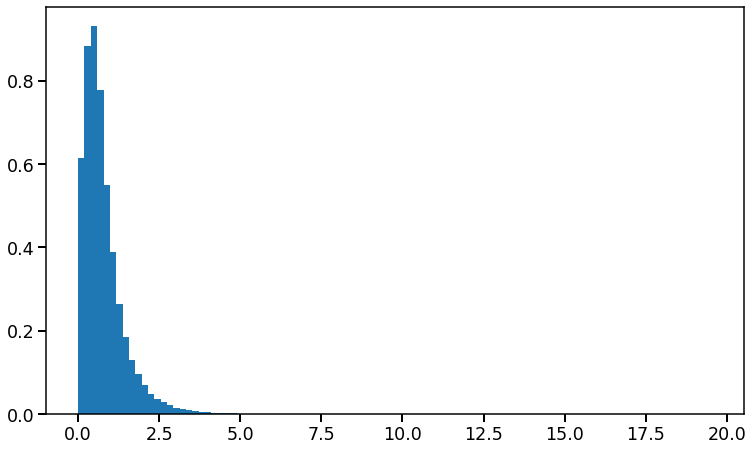

In [156]:
plot_histogram(df, 'U1_r', labels=None, bins=100, log=False)

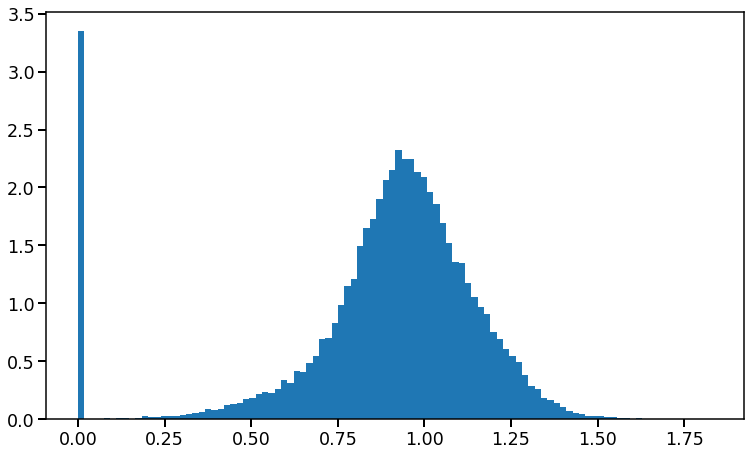

In [211]:
plot_histogram(df, 'f_g_crit_r', labels=None, bins=100, log=False)

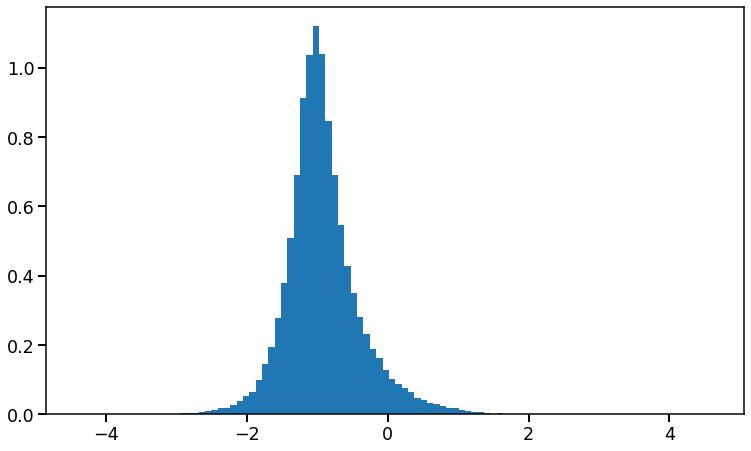

In [153]:
plot_histogram(df[df['N_ratio_r']>0], 'N_ratio_r', labels=None, bins=100, log=True)

In [143]:
from astropy import constants

In [144]:
constants.m_p

<<class 'astropy.constants.codata2018.CODATA2018'> name='Proton mass' value=1.67262192369e-27 uncertainty=5.1e-37 unit='kg' reference='CODATA 2018'>

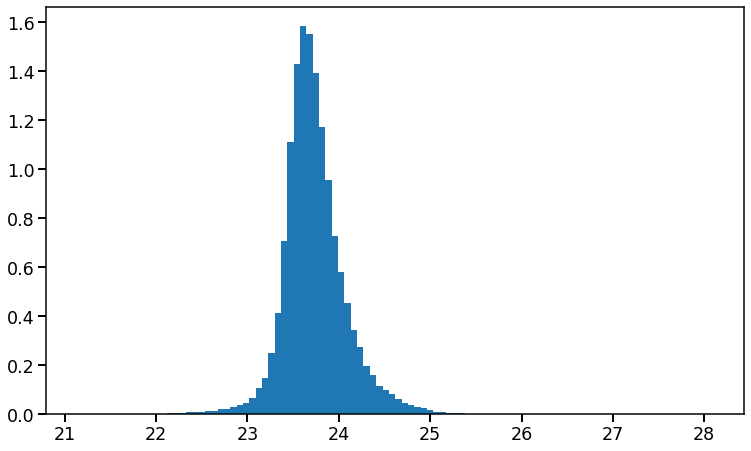

In [134]:
plot_histogram(df[df['Column_dens_r']>0], 'Column_dens_r', labels=None, bins=100, log=True)

In [136]:
df['N_d_r'].describe()

count    6.901300e+04
mean              inf
std               NaN
min      2.854665e+20
25%      3.109707e+21
50%      4.454443e+21
75%      6.589859e+21
max               inf
Name: N_d_r, dtype: float64

In [139]:
df['N_ratio_r'].describe()

count    6.867600e+04
mean     1.809868e+03
std      2.157286e+05
min      0.000000e+00
25%      6.004359e+01
50%      1.044651e+02
75%      2.059522e+02
max      4.054343e+07
Name: N_ratio_r, dtype: float64

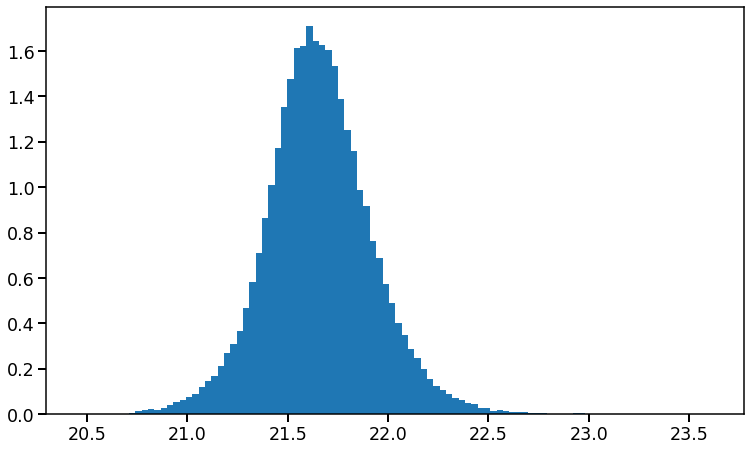

In [138]:
filt = (df['N_d_r']>0) & (df['N_d_r']<np.inf)
plot_histogram(df[filt], 'N_d_r', labels=None, bins=100, log=True)

In [123]:
for element in df.columns:
    print(element)

Z_2r
Z_r
r
SFR_r
SFR_2r
Halo_pos_x
Halo_pos_y
Halo_pos_z
M_gas_2r
V_2r
M_star_2r
M_gas_r
V_r
M_star_r
Redshift
Bol_lum_sf_2r
Ion_em_sf_2r
M_gas_sf_2r
SFR_sf_2r
M_star_sf_2r
V_sf_2r
Z_sf_2r
Bol_lum_sf_r
Ion_em_sf_r
M_gas_sf_r
SFR_sf_r
M_star_sf_r
V_sf_r
Z_sf_r
Tot_Bol_lum_2r
Tot_Ion_em_2r
Tot_Bol_lum_r
Tot_Ion_em_r
Column_height_r
Column_height_2r
Column_dens_r
Column_dens_2r
r_sf_r
r_sf_2r
Sigma_SFR_r
Sigma_SFR_2r
Sigma_SFR_sf_r
Sigma_SFR_sf_2r
Sigma_gas_r
Sigma_gas_2r
Sigma_gas_sf_r
Sigma_gas_sf_2r
Sigma_star_r
Sigma_star_2r
Sigma_star_sf_r
Sigma_star_sf_2r
Ion_flux_r
Ion_flux_2r
Bol_flux_r
Bol_flux_2r
Ion_flux_sf_r
Ion_flux_sf_2r
Bol_flux_sf_r
Bol_flux_sf_2r
Dust_norm_r
Dust_norm_2r
Dust_norm_sf_r
Dust_norm_sf_2r
f_g_r
f_g_2r
f_g_sf_r
f_g_sf_2r
N_d_r
N_d_2r
N_d_sf_r
N_d_sf_2r
sigma_d_H_r
sigma_d_H_2r
sigma_d_H_sf_r
sigma_d_H_sf_2r
p_g_r
p_g_2r
p_g_sf_r
p_g_sf_2r
n_gas_r
n_gas_2r
n_gas_sf_r
n_gas_sf_2r
U_r
U_2r
U_sf_r
U_sf_2r
Column_dens_stroemgren_r
Column_dens_stroemgren_2r
Column_d